In [7]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:

get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/raw/3339_alwadi'))
csv_file = 'Employee Plans.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

df_plans = pd.read_csv(absolute_path)
print(df_plans.head(3))

   TenantId      Id                 FromDate                   ToDate  \
0      3339  204330  2024-06-01 00:00:00.000  2026-12-31 00:00:00.000   
1      3339  204333  2024-01-01 00:00:00.000  2026-12-31 00:00:00.000   
2      3339  204334  2024-01-01 00:00:00.000  2024-12-31 00:00:00.000   

   EmployeeId  PlanId  
0       52102    4694  
1       52111    4694  
2       52120    4694  


In [9]:

get_base_dir = os.path.abspath(os.path.join(os.getcwd(), '../../data/processed/3339_alwadi'))
csv_file = '3339_alwadi_transformation_data.csv'
absolute_path = os.path.join(get_base_dir, csv_file)

DSet = pd.read_csv(absolute_path)

# Merge the datasets on 'EmployeeId'
merged_df = pd.merge(DSet, df_plans[['EmployeeId', 'PlanId']], on='EmployeeId', how='inner')
print(merged_df.head(10))


   EmployeeId   Transdate  DayOfWeek CheckInTime CheckOutTime      hours  \
0       52102  2024-06-03          4    16:00:00     22:00:00   6.000000   
1       52102  2024-06-04          5    07:16:00     21:59:00  14.716667   
2       52102  2024-06-05          5    08:23:00     22:02:00  13.650000   
3       52102  2024-06-06          6    08:26:00     22:00:00  13.566667   
4       52102  2024-06-08          6    08:00:00     21:57:00  13.950000   
5       52102  2024-06-09          0    08:15:00     21:55:00  13.666667   
6       52102  2024-06-10          0    08:03:00     21:48:00  13.750000   
7       52102  2024-06-11          1    15:04:00     21:56:00   6.866667   
8       52102  2024-06-12          1    08:20:00     22:00:00  13.666667   
9       52102  2024-06-13          2    08:04:00     22:00:00  13.933333   

   PlanId  
0    4694  
1    4694  
2    4694  
3    4694  
4    4694  
5    4694  
6    4694  
7    4694  
8    4694  
9    4694  


In [10]:
DSet['Transdate'] = pd.to_datetime(DSet['Transdate'])
df_plans['FromDate'] = pd.to_datetime(df_plans['FromDate'])
df_plans['ToDate'] = pd.to_datetime(df_plans['ToDate'])

# Merge datasets
mergedf = pd.merge(DSet, df_plans,left_on='EmployeeId', right_on='EmployeeId')

# Display the result
mergedf

,EmployeeId,Transdate,DayOfWeek,CheckInTime,CheckOutTime,hours,TenantId,Id,FromDate,ToDate,PlanId
0,52102,2024-06-03,4,16:00:00,22:00:00,6.000000,3339,204330,2024-06-01,2026-12-31,4694
1,52102,2024-06-04,5,07:16:00,21:59:00,14.716667,3339,204330,2024-06-01,2026-12-31,4694
2,52102,2024-06-05,5,08:23:00,22:02:00,13.650000,3339,204330,2024-06-01,2026-12-31,4694
3,52102,2024-06-06,6,08:26:00,22:00:00,13.566667,3339,204330,2024-06-01,2026-12-31,4694
4,52102,2024-06-08,6,08:00:00,21:57:00,13.950000,3339,204330,2024-06-01,2026-12-31,4694
...,...,...,...,...,...,...,...,...,...,...,...
123,52120,2024-07-29,6,06:54:00,21:33:00,14.650000,3339,204334,2024-01-01,2024-12-31,4694
124,52120,2024-07-30,6,06:53:00,21:30:00,14.616667,3339,204334,2024-01-01,2024-12-31,4694
125,52120,2024-07-31,0,06:56:00,21:30:00,14.566667,3339,204334,2024-01-01,2024-12-31,4694
126,52120,2024-08-01,0,06:53:00,12:05:00,5.200000,3339,204334,2024-01-01,2024-12-31,4694


In [11]:

result_df = mergedf[(mergedf['Transdate'] >= mergedf['FromDate']) & 
                      (mergedf['Transdate'] <= mergedf['ToDate'])]

result_df

,EmployeeId,Transdate,DayOfWeek,CheckInTime,CheckOutTime,hours,TenantId,Id,FromDate,ToDate,PlanId
0,52102,2024-06-03,4,16:00:00,22:00:00,6.000000,3339,204330,2024-06-01,2026-12-31,4694
1,52102,2024-06-04,5,07:16:00,21:59:00,14.716667,3339,204330,2024-06-01,2026-12-31,4694
2,52102,2024-06-05,5,08:23:00,22:02:00,13.650000,3339,204330,2024-06-01,2026-12-31,4694
3,52102,2024-06-06,6,08:26:00,22:00:00,13.566667,3339,204330,2024-06-01,2026-12-31,4694
4,52102,2024-06-08,6,08:00:00,21:57:00,13.950000,3339,204330,2024-06-01,2026-12-31,4694
...,...,...,...,...,...,...,...,...,...,...,...
123,52120,2024-07-29,6,06:54:00,21:33:00,14.650000,3339,204334,2024-01-01,2024-12-31,4694
124,52120,2024-07-30,6,06:53:00,21:30:00,14.616667,3339,204334,2024-01-01,2024-12-31,4694
125,52120,2024-07-31,0,06:56:00,21:30:00,14.566667,3339,204334,2024-01-01,2024-12-31,4694
126,52120,2024-08-01,0,06:53:00,12:05:00,5.200000,3339,204334,2024-01-01,2024-12-31,4694


C:\Users\fzmaj\AppData\Local\Temp\ipykernel_22000\3021497783.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  result_df['CheckInHour'] = pd.to_datetime(result_df['CheckInTime']).dt.hour
C:\Users\fzmaj\AppData\Local\Temp\ipykernel_22000\3021497783.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  result_df['CheckOutHour'] = pd.to_datetime(result_df['CheckOutTime']).dt.hour


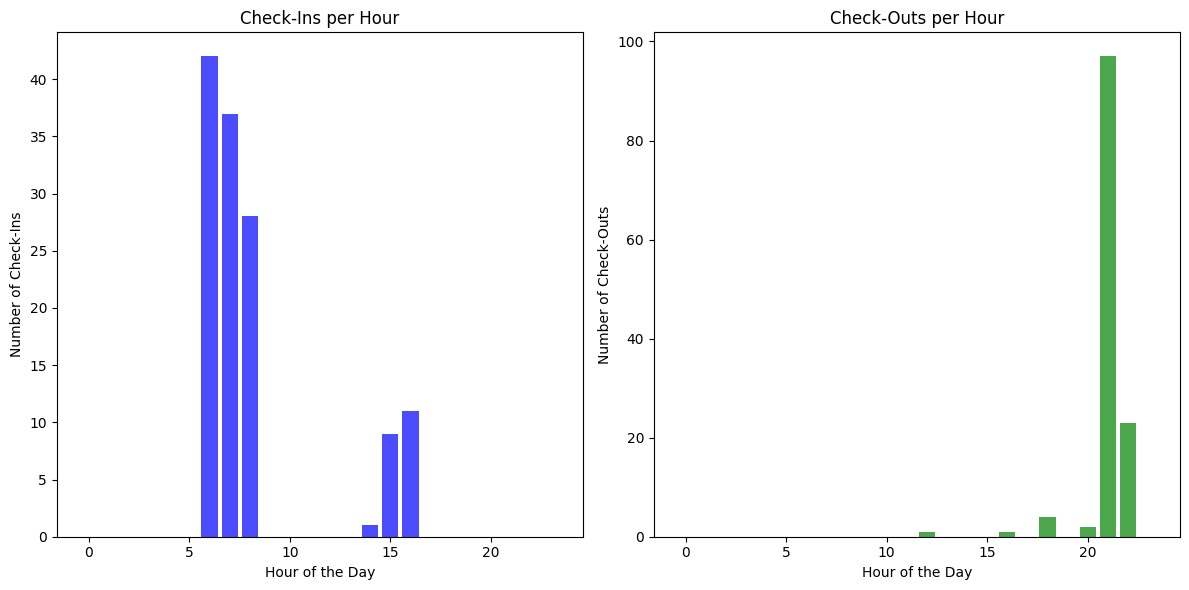

In [12]:

# Convert CheckInTime to minutes since midnight
def time_to_minutes(t):
    h, m, s = map(int, t.split(':'))
    return h * 60 + m + s / 60  # Convert seconds to minutes

# Convert 'CheckInTime' and 'CheckOutTime' from HH:MM format to minutes since midnight
result_df['CheckInHour'] = pd.to_datetime(result_df['CheckInTime']).dt.hour 
result_df['CheckOutHour'] = pd.to_datetime(result_df['CheckOutTime']).dt.hour 


result_df['CheckInMinutes'] = result_df['CheckInTime'].apply(time_to_minutes)
result_df['CheckOutMinutes'] = result_df['CheckOutTime'].apply(time_to_minutes)

# Count check-ins per hour
check_in_counts = result_df['CheckInHour'].value_counts().sort_index()

# Count check-outs per hour
check_out_counts = result_df['CheckOutHour'].value_counts().sort_index()

# Create a DataFrame for plotting
hours = range(24)
check_in_counts = check_in_counts.reindex(hours, fill_value=0)
check_out_counts = check_out_counts.reindex(hours, fill_value=0)

# Plot results
plt.figure(figsize=(12, 6))

# Plot Check-In counts
plt.subplot(1, 2, 1)
plt.bar(check_in_counts.index, check_in_counts.values, color='blue', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Ins')
plt.title('Check-Ins per Hour')

# Plot Check-Out counts
plt.subplot(1, 2, 2)
plt.bar(check_out_counts.index, check_out_counts.values, color='green', alpha=0.7)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Check-Outs')
plt.title('Check-Outs per Hour')

plt.tight_layout()
plt.show()


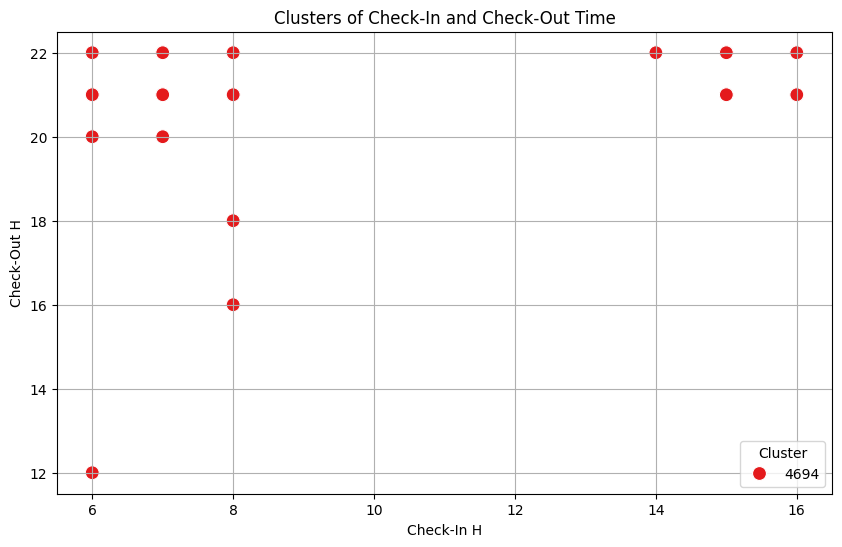

In [13]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='CheckInHour', y='CheckOutHour', hue=result_df['PlanId'], data=result_df, palette='Set1', s=100)
plt.title('Clusters of Check-In and Check-Out Time')
plt.xlabel('Check-In H')
plt.ylabel('Check-Out H')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

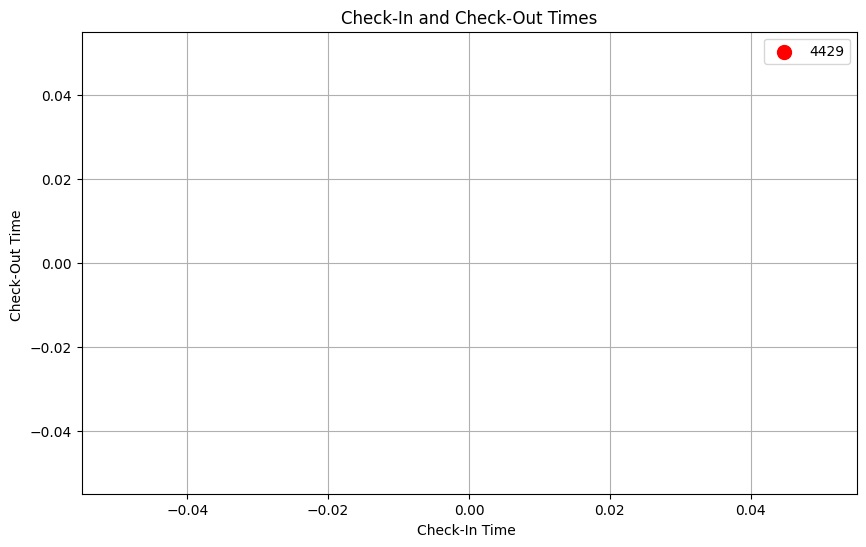

In [15]:

cluster_df = result_df[result_df['PlanId'] == 4429]   # 537 employees ,خطة حر بدون حد ادني جمعة أجازة (7 ص : 23)
#print(cluster_df['EmployeeId'].groupby)
plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='red', label='4429', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()

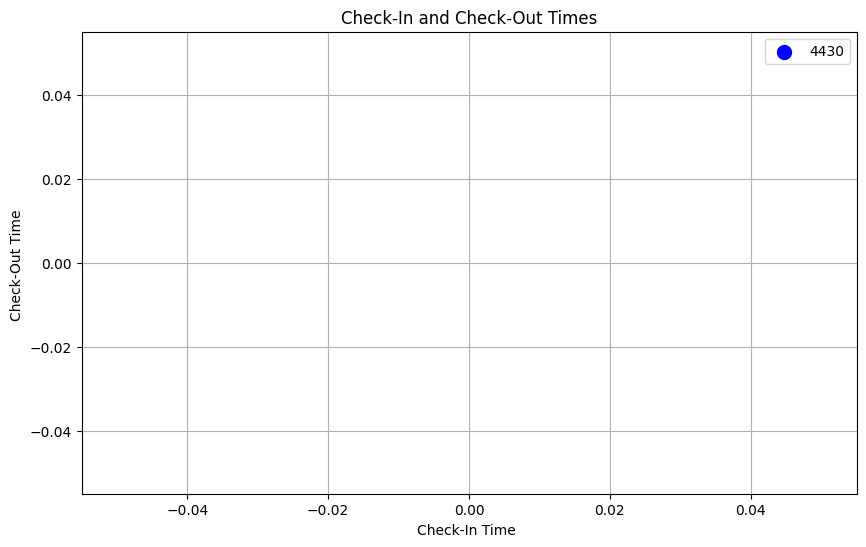

In [16]:

cluster_df = result_df[result_df['PlanId'] == 4427]  # 74 employees ,خطة حر بحد أدنى 6 س بدون راحة ثابتة من(8ص :1م),

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='4430', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()

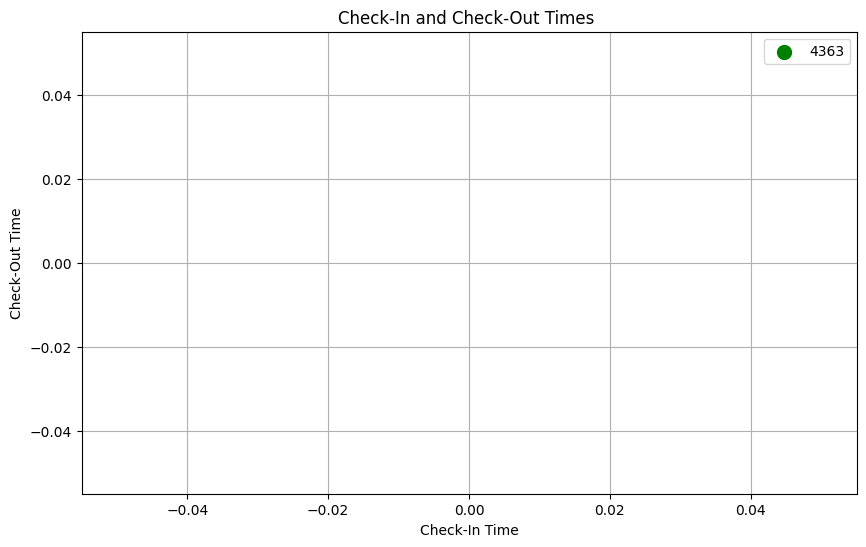

In [17]:
# Filter the DataFrame for Cluster 0
cluster_df1 = result_df[result_df['PlanId'] == 4428]  # 29 employees  ,خطة حر بحد أدنى 6.5 س الجمعة اجاز(من 8ص إلى 1م

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df1['CheckInHour'], cluster_df1['CheckOutHour'], color='green', label='4363', s=100)
plt.title('Check-In and Check-Out Times ')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

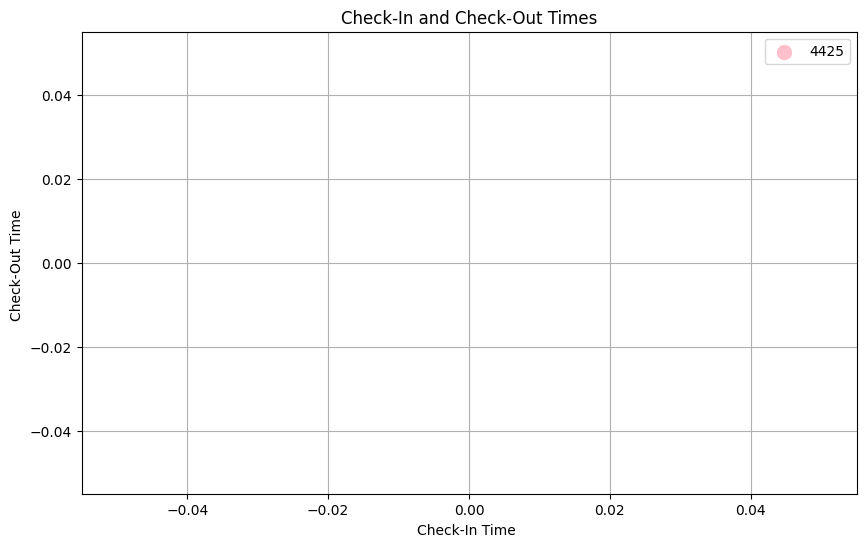

In [18]:
# Filter the DataFrame for Cluster 0
cluster_df = result_df[result_df['PlanId'] == 4358] # 109 employees  "خطة حر حد ادنى 7 س جمعة اجازة "

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='pink', label='4425', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time ')
plt.ylabel('Check-Out Time ')
plt.grid(True)
plt.legend()
plt.show()

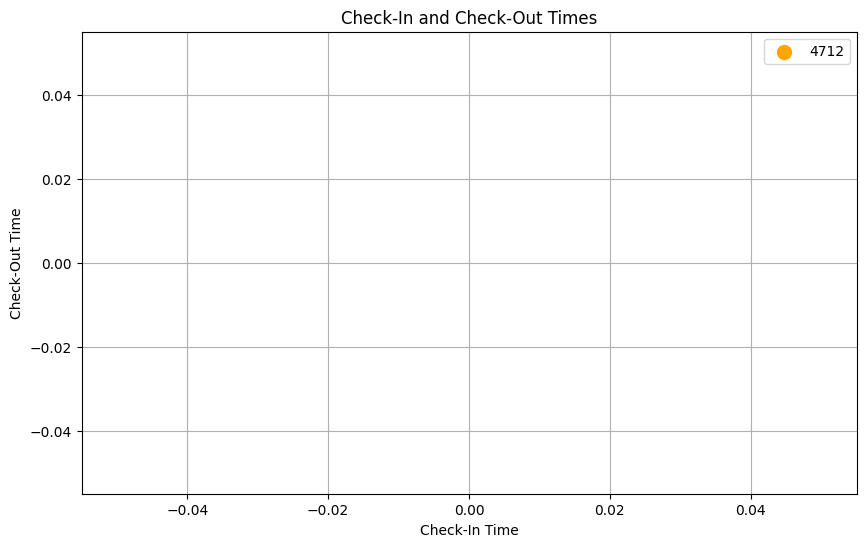

In [19]:
# Filter the DataFrame for Cluster 0
cluster_df = result_df[result_df['PlanId'] == 4712] # 8 Employees ,حر بحد أدنى 6.5 بدون راحة ثابتة,

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='orange', label='4712', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

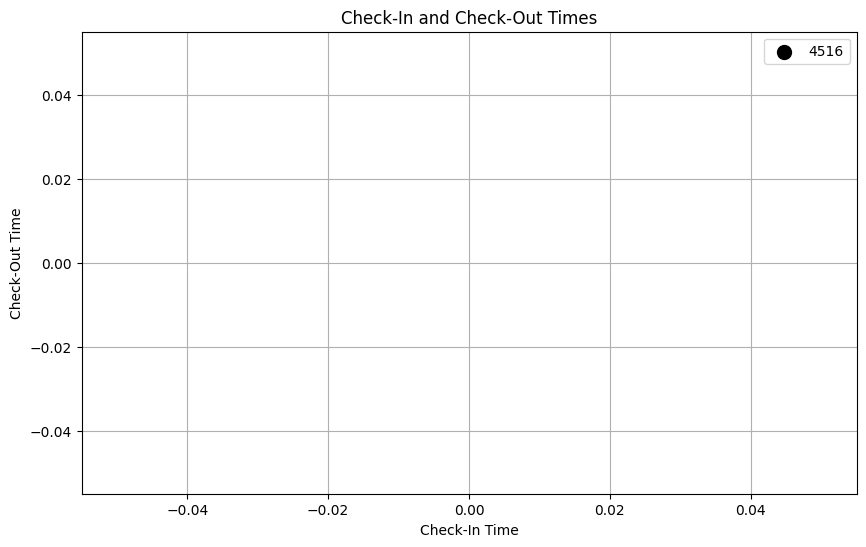

In [20]:

cluster_df = result_df[result_df['PlanId'] == 4516] #  7 Employees      ,خطة حر حد أدنى 6 س الجمعة  أجازة

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='black', label='4516', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

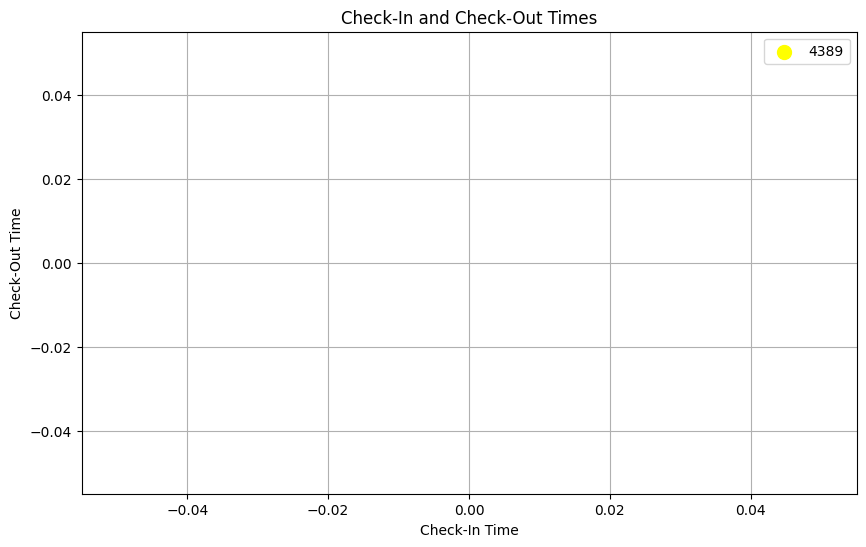

In [21]:
# Filter the DataFrame for Cluster 0
cluster_df = result_df[result_df['PlanId'] == 4389] # 3 Employees  خطة روستر نمطي من 10 ل 17,

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='yellow', label='4389', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

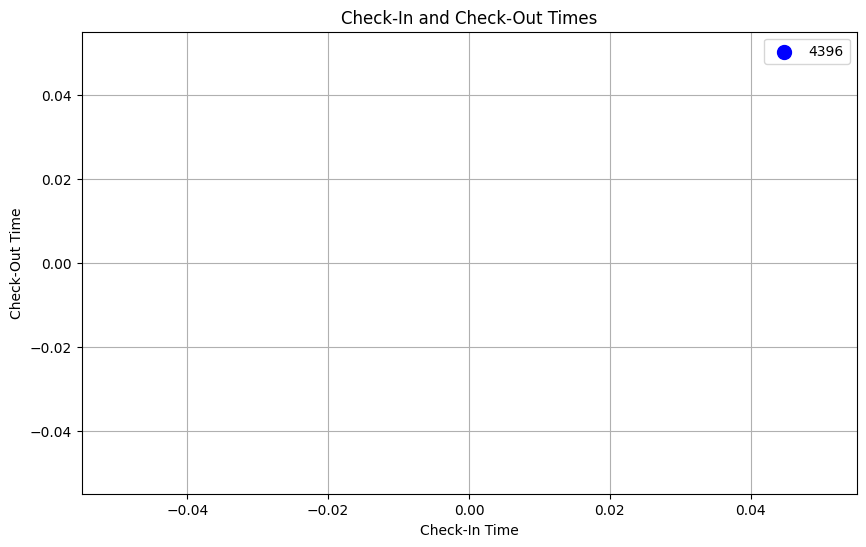

In [22]:

cluster_df = result_df[result_df['PlanId'] == 4396] # 3 Employees  خطة روستر نمطي من 11 ل 18,

plt.figure(figsize=(10, 6))
plt.scatter(cluster_df['CheckInHour'], cluster_df['CheckOutHour'], color='blue', label='4396', s=100)
plt.title('Check-In and Check-Out Times')
plt.xlabel('Check-In Time')
plt.ylabel('Check-Out Time')
plt.grid(True)
plt.legend()
plt.show()

In [23]:
employee_count_per_Shift = result_df.groupby('PlanId')['EmployeeId'].nunique().reset_index()

# Rename columns for clarity
employee_count_per_Shift.columns = ['Shift', 'NumberOfEmployees']

# Print the result
print(employee_count_per_Shift)



   Shift  NumberOfEmployees
0   4694                  3


In [24]:
employees = df_plans.groupby('PlanId')['EmployeeId'].nunique().reset_index()
employees.columns = ['Cluster', 'NumberOfEmployees']
print(employees)

   Cluster  NumberOfEmployees
0     4694                  4
1     4695                  1


In [26]:
# Calculate start and end hours for each cluster
# Calculate statistics for each cluster
cluster_summary = result_df.groupby('PlanId').agg({
    'CheckInHour': [ 'min', 'max'],
    'CheckOutHour': ['min', 'max']
}).reset_index()

# Flatten MultiIndex columns
cluster_summary.columns = ['Cluster','CheckInHour_Min', 'CheckInHour_Max',
                           'CheckOutHour_Min', 'CheckOutHour_Max']

# Print the summary
print(cluster_summary)


   Cluster  CheckInHour_Min  CheckInHour_Max  CheckOutHour_Min  \
0     4694                6               16                12   

   CheckOutHour_Max  
0                22  
